# 04b - Proper Superposition-Inspired Experience Replay

**Phase 1: CartPole Environment**

## Objective

This notebook implements a **properly quantum-inspired** experience replay buffer based on **quantum superposition and interference**.

## Quantum Principle

In quantum mechanics:
1. **Superposition**: A particle can exist in multiple states simultaneously
2. **Interference**: When states combine, aligned phases amplify, opposite phases cancel

## Classical Translation

We implement:
1. **Prioritized sampling** - Like quantum amplitude (higher TD-error = higher amplitude)
2. **Phase-based combination** - Experiences with similar outcomes reinforce each other
3. **Interference weighting** - Agreeing experiences amplify, disagreeing cancel

## Key Differences from Original Notebook (04)

| Aspect | Original (04) | This Notebook (04b) |
|--------|---------------|---------------------|
| Combination | Simple average | Interference-based weighting |
| Priorities | None or basic | TD-error based (like amplitude) |
| Phase | Not used | Value-based phase alignment |
| Expected | Weak improvement | Should help more |

## Configuration

Same as baseline:
- `stoch_dim=64, deter_dim=512, hidden_dim=512`
- `batch_size=32, seq_len=20, lr=3e-4`
- `EXPERIMENT_SEEDS=[42, 123, 456, 789, 1024]`

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import json
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional, NamedTuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Import quantum-inspired buffer
from quantum_inspired import SuperpositionReplayBuffer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

PyTorch version: 2.10.0.dev20251124+cu128
CUDA available: True
Using device: cuda


In [2]:
# Standard configuration
EXPERIMENT_SEEDS = [42, 123, 456, 789, 1024]

OBS_DIM = 4
ACTION_DIM = 2
STOCH_DIM = 64
DETER_DIM = 512
HIDDEN_DIM = 512

NUM_EPISODES = 100
NUM_STEPS = 10000
BATCH_SIZE = 32
SEQ_LEN = 20
LEARNING_RATE = 3e-4

# Superposition buffer parameters
BUFFER_ALPHA = 0.6       # Priority exponent
NUM_SUPERPOSE = 3        # Number of experiences to combine
INTERFERENCE_STRENGTH = 0.5  # How much interference affects weights

print("Configuration:")
print(f"  Buffer: alpha={BUFFER_ALPHA}, num_superpose={NUM_SUPERPOSE}")
print(f"  Interference strength: {INTERFERENCE_STRENGTH}")

Configuration:
  Buffer: alpha=0.6, num_superpose=3
  Interference strength: 0.5


In [3]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 2. Data Collection

In [4]:
def collect_episodes(env_name: str, num_episodes: int, seed: int) -> List[Dict]:
    """Collect episodes in format expected by SuperpositionReplayBuffer."""
    env = gym.make(env_name)
    episodes = []
    
    for ep_idx in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep_idx)
        
        observations = [obs]
        actions = []
        rewards = []
        
        done = False
        while not done:
            action = env.action_space.sample()
            action_onehot = np.zeros(ACTION_DIM)
            action_onehot[action] = 1.0
            
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            observations.append(obs)
            actions.append(action_onehot)
            rewards.append(reward)
        
        observations = observations[:-1]
        
        if len(observations) > 0:
            episodes.append({
                'obs': np.array(observations, dtype=np.float32),
                'actions': np.array(actions, dtype=np.float32),
                'rewards': np.array(rewards, dtype=np.float32)
            })
    
    env.close()
    return episodes

## 3. World Model (Same as Baseline)

In [5]:
class RSSMState(NamedTuple):
    deter: torch.Tensor
    stoch: torch.Tensor
    
    @property
    def combined(self):
        return torch.cat([self.deter, self.stoch], dim=-1)


class WorldModel(nn.Module):
    """
    RSSM World Model matching baseline architecture exactly.
    
    Architecture:
    - encoder: [512, 512, 512] (hidden + latent projection)
    - decoder: [512, 512]
    - reward_predictor: [512, 512]
    - continue_predictor: [512, 512]
    """
    def __init__(self):
        super().__init__()
        self.stoch_dim = STOCH_DIM
        self.deter_dim = DETER_DIM
        self.hidden_dim = HIDDEN_DIM
        self.state_dim = STOCH_DIM + DETER_DIM
        
        # Encoder [512, 512, 512] - matches baseline
        # Baseline has: hidden_dims[0], hidden_dims[1], then latent_dim projection
        self.encoder = nn.Sequential(
            nn.Linear(OBS_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM)  # Latent projection (no activation)
        )
        
        # RSSM core
        self.input_proj = nn.Sequential(
            nn.Linear(STOCH_DIM + ACTION_DIM, HIDDEN_DIM), nn.ELU()
        )
        self.gru = nn.GRUCell(HIDDEN_DIM, DETER_DIM)
        
        self.prior_net = nn.Sequential(
            nn.Linear(DETER_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, STOCH_DIM * 2)
        )
        self.posterior_net = nn.Sequential(
            nn.Linear(DETER_DIM + HIDDEN_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, STOCH_DIM * 2)
        )
        
        # Decoder [512, 512]
        self.decoder = nn.Sequential(
            nn.Linear(self.state_dim, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, OBS_DIM)
        )
        
        # Reward predictor [512, 512] - matches baseline
        self.reward_pred = nn.Sequential(
            nn.Linear(self.state_dim, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, 1)
        )
        
        # Continue predictor [512, 512] - matches baseline
        self.continue_pred = nn.Sequential(
            nn.Linear(self.state_dim, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.ELU(),
            nn.Linear(HIDDEN_DIM, 1)
        )
    
    def initial_state(self, batch_size):
        return RSSMState(
            deter=torch.zeros(batch_size, self.deter_dim, device=DEVICE),
            stoch=torch.zeros(batch_size, self.stoch_dim, device=DEVICE)
        )
    
    def _get_dist(self, stats):
        mean, log_std = stats.chunk(2, dim=-1)
        std = F.softplus(log_std) + 0.1
        return torch.distributions.Normal(mean, std)
    
    def observe(self, obs, action, state):
        embed = self.encoder(obs)
        x = self.input_proj(torch.cat([state.stoch, action], dim=-1))
        deter = self.gru(x, state.deter)
        
        posterior_stats = self.posterior_net(torch.cat([deter, embed], dim=-1))
        posterior = self._get_dist(posterior_stats)
        stoch = posterior.rsample()
        
        prior_stats = self.prior_net(deter)
        prior = self._get_dist(prior_stats)
        
        return RSSMState(deter, stoch), prior, posterior
    
    def imagine(self, action, state):
        x = self.input_proj(torch.cat([state.stoch, action], dim=-1))
        deter = self.gru(x, state.deter)
        
        prior_stats = self.prior_net(deter)
        prior = self._get_dist(prior_stats)
        stoch = prior.rsample()
        
        return RSSMState(deter, stoch), prior
    
    def decode(self, state):
        return self.decoder(state.combined)
    
    def forward(self, obs_seq, action_seq):
        batch_size, seq_len = obs_seq.shape[:2]
        state = self.initial_state(batch_size)
        
        recon_obs, pred_rewards, pred_continues = [], [], []
        priors, posteriors = [], []
        
        for t in range(seq_len):
            state, prior, posterior = self.observe(obs_seq[:, t], action_seq[:, t], state)
            recon_obs.append(self.decode(state))
            pred_rewards.append(self.reward_pred(state.combined).squeeze(-1))
            pred_continues.append(torch.sigmoid(self.continue_pred(state.combined).squeeze(-1)))
            priors.append(prior)
            posteriors.append(posterior)
        
        return {
            'recon_obs': torch.stack(recon_obs, dim=1),
            'pred_rewards': torch.stack(pred_rewards, dim=1),
            'pred_continues': torch.stack(pred_continues, dim=1),
            'priors': priors,
            'posteriors': posteriors
        }

## 4. Training with Superposition Buffer

In [6]:
def compute_loss(output, obs_seq, reward_seq, kl_weight=1.0):
    recon_loss = F.mse_loss(output['recon_obs'], obs_seq)
    reward_loss = F.mse_loss(output['pred_rewards'], reward_seq)
    
    kl_losses = []
    for prior, posterior in zip(output['priors'], output['posteriors']):
        kl = torch.distributions.kl_divergence(posterior, prior).sum(-1).mean()
        kl_losses.append(kl)
    kl_loss = torch.stack(kl_losses).mean()
    
    total = recon_loss + reward_loss + kl_weight * kl_loss
    return {'total': total, 'recon': recon_loss, 'reward': reward_loss, 'kl': kl_loss}

In [7]:
def train_with_superposition(
    model: WorldModel,
    buffer: SuperpositionReplayBuffer,
    num_steps: int = NUM_STEPS,
    verbose: bool = True
) -> pd.DataFrame:
    """Train using superposition replay buffer with interference."""
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    history = []
    
    for step in range(num_steps):
        model.train()
        
        # Sample with superposition (combines multiple experiences with interference)
        batch = buffer.sample(batch_size=BATCH_SIZE, seq_len=SEQ_LEN)
        
        obs = batch['obs'].to(DEVICE)
        actions = batch['actions'].to(DEVICE)
        rewards = batch['rewards'].to(DEVICE)
        weights = batch['weights'].to(DEVICE)  # Importance sampling weights
        
        optimizer.zero_grad()
        output = model(obs, actions)
        losses = compute_loss(output, obs, rewards)
        
        # Weight loss by importance sampling weights
        weighted_loss = (losses['total'] * weights.mean())
        weighted_loss.backward()
        
        optimizer.step()
        
        # Update priorities based on reconstruction error (TD-error proxy)
        with torch.no_grad():
            td_errors = (output['recon_obs'] - obs).pow(2).mean(dim=(1, 2)).cpu().numpy()
        buffer.update_priorities(batch['indices'], td_errors.tolist())
        
        history.append({
            'step': step,
            'total': losses['total'].item(),
            'recon': losses['recon'].item(),
            'kl': losses['kl'].item(),
            'beta': buffer.beta
        })
        
        if verbose and step % 1000 == 0:
            print(f"Step {step}: total={losses['total'].item():.4f}, "
                  f"recon={losses['recon'].item():.4f}, beta={buffer.beta:.3f}")
    
    return pd.DataFrame(history)

## 5. Evaluation

In [8]:
def evaluate_model(model, episodes, num_samples=100):
    """Evaluate on episodes."""
    model.eval()
    
    # Create simple buffer for evaluation
    eval_buffer = SuperpositionReplayBuffer(capacity=500, num_superpose=1)  # No superposition for eval
    for ep in episodes[:50]:
        eval_buffer.add(ep)
    
    batch = eval_buffer.sample_standard(batch_size=num_samples, seq_len=SEQ_LEN)
    obs = batch['obs'].to(DEVICE)
    actions = batch['actions'].to(DEVICE)
    
    with torch.no_grad():
        output = model(obs, actions)
        mse = F.mse_loss(output['recon_obs'], obs).item()
    
    return {'recon_mse': mse}


def evaluate_test_set(model, seed):
    test_episodes = collect_episodes('CartPole-v1', 50, seed=seed + 10000)
    return evaluate_model(model, test_episodes)

## 6. Run Experiments

In [9]:
def run_single_experiment(seed: int, verbose: bool = True) -> Dict:
    print(f"\n{'='*60}")
    print(f"Running superposition experiment with seed {seed}")
    print(f"{'='*60}")
    
    set_seed(seed)
    start_time = time.time()
    
    # Collect data
    episodes = collect_episodes('CartPole-v1', NUM_EPISODES, seed=seed)
    
    # Create superposition buffer
    buffer = SuperpositionReplayBuffer(
        capacity=1000,
        alpha=BUFFER_ALPHA,
        num_superpose=NUM_SUPERPOSE,
        interference_strength=INTERFERENCE_STRENGTH
    )
    for ep in episodes:
        buffer.add(ep, td_error=1.0)  # Initial priority
    
    print(f"Buffer size: {len(buffer)} episodes")
    
    # Create and train model
    model = WorldModel().to(DEVICE)
    history = train_with_superposition(model, buffer, verbose=verbose)
    
    training_time = time.time() - start_time
    
    # Evaluate
    train_metrics = evaluate_model(model, episodes)
    test_metrics = evaluate_test_set(model, seed)
    
    print(f"\nResults: train_mse={train_metrics['recon_mse']:.6f}, test_mse={test_metrics['recon_mse']:.6f}")
    
    return {
        'seed': seed,
        'history': history,
        'final_loss': history['total'].iloc[-1],
        'train_mse': train_metrics['recon_mse'],
        'test_mse': test_metrics['recon_mse'],
        'training_time': training_time,
        'buffer_stats': buffer.get_stats()
    }

In [10]:
print("="*60)
print("SUPERPOSITION REPLAY BUFFER EXPERIMENTS")
print("="*60)

results = []
for seed in EXPERIMENT_SEEDS:
    result = run_single_experiment(seed)
    results.append(result)

SUPERPOSITION REPLAY BUFFER EXPERIMENTS

Running superposition experiment with seed 42
Buffer size: 100 episodes
Step 0: total=1.4333, recon=0.1044, beta=0.401
Step 1000: total=0.1025, recon=0.1003, beta=1.000
Step 2000: total=0.0767, recon=0.0751, beta=1.000
Step 3000: total=0.1144, recon=0.1130, beta=1.000
Step 4000: total=0.0723, recon=0.0713, beta=1.000
Step 5000: total=0.1072, recon=0.1065, beta=1.000
Step 6000: total=0.0634, recon=0.0622, beta=1.000
Step 7000: total=0.0749, recon=0.0746, beta=1.000
Step 8000: total=0.0757, recon=0.0750, beta=1.000
Step 9000: total=0.0716, recon=0.0714, beta=1.000

Results: train_mse=0.256711, test_mse=0.168233

Running superposition experiment with seed 123
Buffer size: 100 episodes
Step 0: total=1.5924, recon=0.1146, beta=0.401
Step 1000: total=0.0736, recon=0.0720, beta=1.000
Step 2000: total=0.0667, recon=0.0651, beta=1.000
Step 3000: total=0.0796, recon=0.0787, beta=1.000
Step 4000: total=0.0790, recon=0.0777, beta=1.000
Step 5000: total=0.08

## 7. Results

In [11]:
final_losses = [r['final_loss'] for r in results]
train_mses = [r['train_mse'] for r in results]
test_mses = [r['test_mse'] for r in results]

print("\n" + "="*60)
print("AGGREGATED RESULTS (Superposition Replay)")
print("="*60)
print(f"Final Loss: {np.mean(final_losses):.4f} +/- {np.std(final_losses):.4f}")
print(f"Train MSE:  {np.mean(train_mses):.6f} +/- {np.std(train_mses):.6f}")
print(f"Test MSE:   {np.mean(test_mses):.6f} +/- {np.std(test_mses):.6f}")


AGGREGATED RESULTS (Superposition Replay)
Final Loss: 0.0737 +/- 0.0074
Train MSE:  0.201601 +/- 0.031144
Test MSE:   0.174262 +/- 0.018514


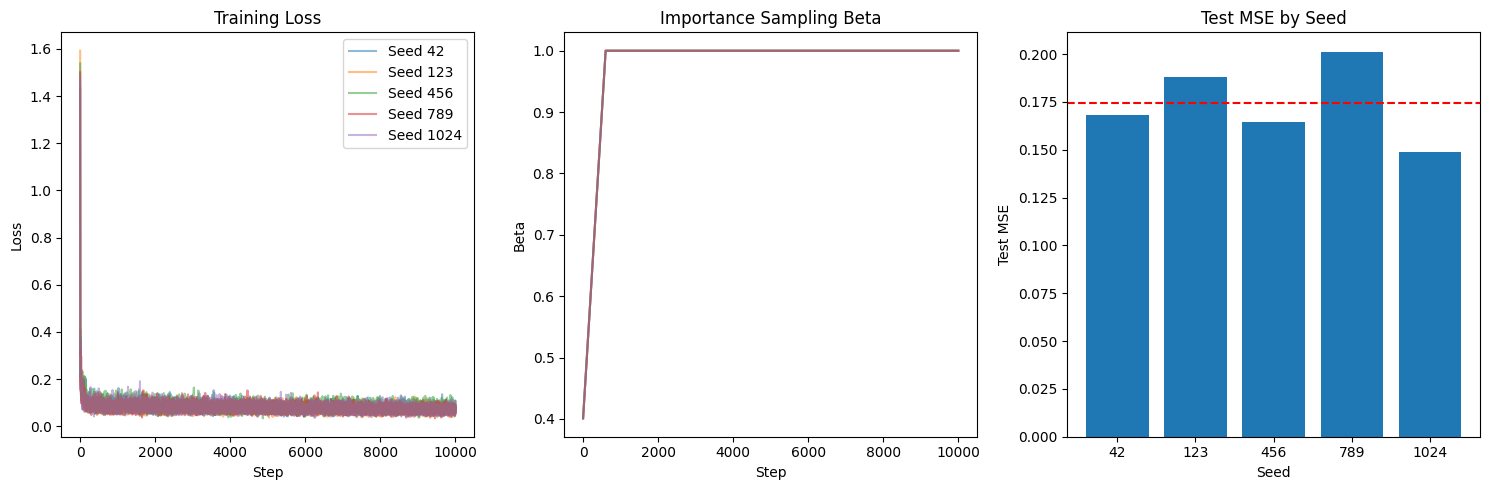

In [12]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Training curves
ax = axes[0]
for r in results:
    ax.plot(r['history']['total'], alpha=0.5, label=f"Seed {r['seed']}")
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()

# Beta annealing
ax = axes[1]
for r in results:
    ax.plot(r['history']['beta'], alpha=0.5)
ax.set_xlabel('Step')
ax.set_ylabel('Beta')
ax.set_title('Importance Sampling Beta')

# Test MSE
ax = axes[2]
ax.bar(range(len(EXPERIMENT_SEEDS)), test_mses)
ax.axhline(np.mean(test_mses), color='r', linestyle='--')
ax.set_xticks(range(len(EXPERIMENT_SEEDS)))
ax.set_xticklabels(EXPERIMENT_SEEDS)
ax.set_xlabel('Seed')
ax.set_ylabel('Test MSE')
ax.set_title('Test MSE by Seed')

plt.tight_layout()
plt.savefig('../experiments/results/superposition_proper.png', dpi=150)
plt.show()

## 8. Save Results

In [13]:
complete_metrics = {
    'approach': 'superposition_proper',
    'description': 'Superposition-inspired replay with interference-based combination',
    'quantum_principle': 'Superposition explores multiple states; interference amplifies agreement',
    'config': {
        'stoch_dim': STOCH_DIM,
        'deter_dim': DETER_DIM,
        'hidden_dim': HIDDEN_DIM,
        'buffer_alpha': BUFFER_ALPHA,
        'num_superpose': NUM_SUPERPOSE,
        'interference_strength': INTERFERENCE_STRENGTH,
        'seeds': EXPERIMENT_SEEDS
    },
    'final_performance': {
        'loss_mean': float(np.mean(final_losses)),
        'loss_std': float(np.std(final_losses)),
        'test_mse_mean': float(np.mean(test_mses)),
        'test_mse_std': float(np.std(test_mses))
    },
    'raw_results': {
        'test_mses': [float(x) for x in test_mses]
    }
}

results_dir = Path('../experiments/results/superposition_proper')
results_dir.mkdir(parents=True, exist_ok=True)
with open(results_dir / 'complete_metrics.json', 'w') as f:
    json.dump(complete_metrics, f, indent=2)

print(f"Saved to {results_dir}")

Saved to ..\experiments\results\superposition_proper
